In [1]:
#Library
import numpy as np
import pandas as pd
import time as tm
# to integrate
from scipy import interpolate
import scipy.integrate as integrate
import matplotlib.pyplot as plt

---

# Finite element method (FEM 1D)

It is a method for an approximate solution of an PDE.

The finite element method (FEM) breaks the space up into multiple geometric elements, determinines an approximate form for the solution appropiate to each element, and then matches the solution up at the domain edges. Although finite differences are simpler to implement than FEM, they are less robust mathematically and les efficiente in terms of computer time for big problems. The FEM with varios preprogramed multigird packages has a very much become the standar for large scale and practical applications.

## Example: The Poisson's equation


$$-\dfrac{d^2 U(x)}{dx^2}= 4\pi\rho(x)\hspace{1 cm} 0\leq x\leq 1$$
with $\rho = \dfrac{1}{4\pi}$ as a aparticular case, the EDO is

$$-\dfrac{d^2 U(x)}{dx^2}= 1\hspace{1 cm} 0\leq x \leq 1$$

with Dirichlet conditions $U(0)=0, U(1)=1$, the solution is $U(x)=-\dfrac{x}{2}(x-3)$. Let's compute the solution using FEM as an ilustration.


In a FEM, the domain in which the PDE is solved is split into
finite subdomains, called **elements**, and a trial solution to the PDE in each subdomain is hypothesized.
Then the parameters of the trial solution are adjusted to
obtain a best fit (“Solving Systems of Equations with Matrices; Data Fitting”) to the exact solution.
The numerically intensive work is in finding the best values for these parameters and in matching the trial solutions
for the different subdomains.

A FEM solution follows six basic steps:

1. Derivation of a **weak form of the PDE**. This is equivalent to a least-squares
minimization of the integral of the difference between the approximate and
exact solutions.
2. Discretization of the computational domains.
3. Generation of interpolating or trial functions.
4. Assembly of the stiffness (rigidez) matrix and load vector.
5. Implementation of the boundary conditions.
6. Solution of the resulting linear system of equations.

### Weak form of PDF

Let's use the Posisson's equation as example. We assume that we have an approximate or **trial solution Φ(x)** that vanishes at the
endpoints, Φ(a) = Φ(b) = 0 (we satisfy the boundary conditions later). We multiply both sides of the diffrerential equation

$$-\frac{d^{2}U(x)}{dx^{2}}\Phi(x) = 4\pi\,\rho(x)\,\Phi(x)$$

Integrating by parts we get the weak form:

\begin{align*}
- \int_a^b dx \, \frac{d^2 U(x)}{dx^2} \, \Phi(x)
&= \int_a^b dx \, 4\pi \rho(x) \, \Phi(x), \\[6pt]
- \left. \frac{dU(x)}{dx} \Phi(x) \right|_a^b
+ \int_a^b dx \, \frac{dU(x)}{dx} \, \Phi'(x)
&= \int_a^b dx \, 4\pi \rho(x) \, \Phi(x).
\end{align*}

$$\int_a^b dx \, \frac{dU(x)}{dx} \, \Phi'(x)
= \int_a^b dx \, 4\pi \rho(x) \, \Phi(x).
\tag{1}
$$

### Galerkin spectral decomposition

We realize an stepwise procedure. We split the full domain of the PDE into subdomains (elements), find approximate
solutions within each element, and then match the elemental solutions onto each other. For our 1-D problem the subdomain elements are straight lines of equal length, while for a 2-D problem, the elements can be parallelograms or triangles, etc.

We proposed an expansion of $U(x)$ in terms of a set of **basis** functions $\phi_i(x)$ :

$$U(x)=\sum_{j=0}^{N-1}\alpha_j\phi_j(x) \tag{2}$$

This expansion is called a spectral decomposition (in order to satisfy the boundary conditions, we will later add another term to the expansion). If the sizes of the finite elements are made sufficiently small, then good accuracy is obtained
with simple piecewise-continuous basis functions, such as the **triangles or hat** in Figure


![A set of overlapping triangles](https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/triangle.png)

![A set of overlapping triangles](drive/MyDrive/Colab\ Notebooks/Fisica_Computacional_1/figures/triangle.png)

we use basis functions $\phi_i$ that form a triangle or “hat” between $x_{i-1}$ and $x_{i+1}$ and equal 1 at :

\begin{equation}
\phi_i(x) =
\begin{cases}
0, & \text{for } x < x_{i-1}, \text{ or } x > x_{i+1}, \\[6pt]
\dfrac{x - x_{i-1}}{h_i}, & \text{for } x_{i-1} \le x \le x_i, \\[10pt]
\dfrac{x_{i+1} - x}{h_i}, & \text{for } x_i \le x \le x_{i+1},
\end{cases}
\quad \left( h_i = x_{i+1} - x_i \right).
\tag{3}
\end{equation}

Because we have chosen $\phi_i(x_i) = 1$, the values of the expansion coefficients $\alpha_i$
equal the values of the solution at the nodes (to-be-determined) :

\begin{equation}
U(x_i) = \sum_{i=0}^{N-1} \alpha_i \phi_i(x_i)
= \alpha_i,
\tag{4}
\end{equation}

\begin{equation}
\Rightarrow \quad U(x) = \sum_{j=0}^{N-1} U(x_j)\,\phi_j(x).
\tag{5}
\end{equation}

Consequently, you can think of the hat functions as **linear interpolations** between
the solution at the nodes.

Let's find the $\alpha$ coeffitients.

## Solution via Linear equations

Inserting $U(x)$ in eq.(1) convert the problem into matrix problem:

\begin{equation}
\int_a^b dx \, \frac{d}{dx} \left( \sum_{j=0}^{N-1} \alpha_j \phi_j(x) \right)
\frac{d\Phi}{dx}
=
\int_a^b dx \, 4\pi \rho(x)\, \Phi(x).
\end{equation}

By successively selecting $\Phi(x) = \phi_0, \phi_1, \ldots, \phi_{N-1}$, we obtain $N$ simultaneous linear equations for the unknown $\alpha_j$’s:

\begin{equation}
\int_a^b dx \,(\frac{d\phi_i}{dx}) \frac{d}{dx} \left( \sum_{j=0}^{N-1} \alpha_j \phi_j(x) \right)
=
\int_a^b dx \, 4\pi \rho(x)\, \phi_i(x),
\quad i = 0, \ldots, N-1.
\tag{7}
\end{equation}


We factor out the unknown $\alpha_j$ and write out the equations explicitly:

$$
\begin{align*}
\alpha_0 \int_a^b \phi_{0'} \phi_{0'} \, dx
+ \alpha_1 \int_a^b \phi_{0'} \phi_{1'} \, dx
+ \cdots
+ \alpha_{N-1} \int_a^b \phi_{0'} \phi_{N-1}' \, dx
&= \int_a^b 4\pi \rho \, \phi_0 \, dx, \\[6pt]
\alpha_0 \int_a^b \phi_{1'} \phi_{0'} \, dx
+ \alpha_1 \int_a^b \phi_{1'} \phi_{1'} \, dx
+ \cdots
+ \alpha_{N-1} \int_a^b \phi_1' \phi_{N-1}' \, dx
&= \int_a^b 4\pi \rho \, \phi_1 \, dx, \\
&\vdots \\
\alpha_0 \int_a^b \phi_{N-1}' \phi_{0'} \, dx
+ \alpha_1 \int_a^b \phi_{N-1}' \phi_{1'} \, dx
+ \cdots
+ \alpha_{N-1} \int_a^b \phi_{N-1}' \phi_{N-1}' \, dx
&= \int_a^b 4\pi \rho \, \phi_{N-1} \, dx.
\end{align*}
$$

Because we have chosen the $\phi_i$’s to be the simple hat functions, the derivatives are easy to evaluate analytically (otherwise they can be done numerically):

\begin{equation}
\frac{d\phi_{i,i+1}}{dx} =
\begin{cases}
0, & x < x_{i-1}, \text{ or } x_{i+1} < x, \\[6pt]
\dfrac{1}{h_{i-1}}, & x_{i-1} \le x \le x_i, \\[10pt]
-\dfrac{1}{h_i}, & x_i \le x \le x_{i+1},
\end{cases}
\qquad
\begin{cases}
0, & x < x_i, \text{ or } x_{i+2} < x, \\[6pt]
\dfrac{1}{h_{i}}, & x_i \le x \le x_{i+1}, \\[10pt]
-\dfrac{1}{h_{i+1}}, & x_{i+1} \le x \le x_{i+2}.
\end{cases}
\tag{8}
\end{equation}

The integrals to evaluate are

$$
\begin{align*}
\int_{x_{i-1}}^{x_{i+1}} dx \, (\phi_{i'})^2
&= \int_{x_{i-1}}^{x_i} dx \, \frac{1}{h_{i-1}^2}
+ \int_{x_i}^{x_{i+1}} dx \, \frac{1}{h_i^2}
= \frac{1}{h_{i-1}} + \frac{1}{h_i}, \\[8pt]
\int_{x_{i-1}}^{x_{i+1}} dx \, \phi_{i'} \phi_{i+1}'
&= \int_{x_i}^{x_{i+1}} dx \, \phi_{i'} \phi_{i+1}'
= \int_{x_i}^{x_{i+1}} dx \, \frac{-1}{h_i^2}
= -\frac{1}{h_i}, \\[8pt]
\int_{x_{i-1}}^{x_{i+1}} dx \, (\phi_{i+1}')^2
&= \int_{x_i}^{x_{i+1}} dx \, (\phi_{i+1}')^2
+ \int_{x_{i+1}}^{x_{i+2}} dx \, \frac{1}{h_{i+1}^2}
= \frac{1}{h_i} + \frac{1}{h_{i+1}}.
\end{align*}
$$

We rewrite these equations in the standard matrix form with $\boldsymbol{\alpha}$ constructed
from the unknown $\alpha_j$’s, and the tridiagonal stiffness (rigidez) matrix $\mathbf{A}$ constructed from
the integrals above.


The system can be written in matrix form as

$$\mathbf{A}\,\boldsymbol{\alpha} = \mathbf{b},
$$

where $\boldsymbol{\alpha} = (\alpha_0, \alpha_1, \dots, \alpha_{N-1})^T$ and
$\mathbf{b} = (b_0, b_1, \dots, b_{N-1})^T$ with
$b_i = \int_a^b 4\pi \rho(x)\,\phi_i(x)\,dx.$

The stiffness matrix $\mathbf{A}$ is tridiagonal and given by

$
\mathbf{A} =
\begin{pmatrix}
\frac{1}{h_0} + \frac{1}{h_1} & -\frac{1}{h_1} & 0 & \cdots & 0 \\
-\frac{1}{h_1} & \frac{1}{h_1} + \frac{1}{h_2} & -\frac{1}{h_2} & \cdots & 0 \\
0 & -\frac{1}{h_2} & \frac{1}{h_2} + \frac{1}{h_3} & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & -\frac{1}{h_{N-2}} \\
0 & 0 & 0 & -\frac{1}{h_{N-2}} & \frac{1}{h_{N-2}} + \frac{1}{h_{N-1}}
\end{pmatrix}.
$

In compact form, the entries of $\mathbf{A}$ are
$
A_{i,i} = \frac{1}{h_{i-1}} + \frac{1}{h_i}, \quad
A_{i,i+1} = -\frac{1}{h_i}, \quad
A_{i,i-1} = -\frac{1}{h_{i-1}}.$

Note that the elements in $A$ are just combinations of inverse step sizes and do no change for different charge density $\rho(x)$.

## Dirichlet Boundary Conditions

Because the basis functions vanish at the endpoints, a solution expanded in them
also vanishes there. This will not do in general, and so we add the particular
solution $U_a\phi_0(x)$ and $U_b\phi_{N-1}(x)$ , which satisfies the boundary conditions:

$U(x)=\sum_{j=0}^{N-1}\alpha_j \, \phi_j(x) + U_a\,\phi_0(x) +U_b\,\phi_{N-1}(x)$,
where $U_i=U(x_i)$.

Them, the weak form is considering $U_a\phi_0(x)$:

$$\int_a^b dx \, \frac{dU(x)}{dx} \, \Phi'(x)
= \int_a^b dx \, 4\pi \rho(x) \, \Phi(x).
$$

\begin{equation}
\int_a^b dx \, \Phi'\frac{d}{dx} \left( \sum_{j=0}^{N-1} \alpha_j \phi_j(x)+U_a \, \phi_0(x) \right)
=
\int_a^b dx \, 4\pi \rho(x)\, \Phi(x).
\end{equation}


\begin{align*}
\alpha_0\int_a^b \phi_0' \phi_0' \, dx
+ \alpha_1 \int_a^b \phi_0' \phi_1' \, dx
+ \cdots
+ \alpha_{N-1} \int_a^b \phi_0' \phi_{N-1}' \, dx +  U_a\int_a^b \phi_0' \phi_0' \, dx
&= \int_a^b 4\pi \rho \, \phi_0 \, dx \\[6pt]
\alpha_0 \int_a^b \phi_1' \phi_0' \, dx
+ \alpha_1\int_a^b \phi_1' \phi_1' \, dx
+ \cdots
+ \alpha_{N-1} \int_a^b \phi_1' \phi_{N-1}' \, dx  +  U_a\int_a^b \phi_1' \phi_0' \, dx
&= \int_a^b 4\pi \rho \, \phi_1 \, dx, \\
&\vdots \\
\alpha_0 \int_a^b \phi_{N-1}' \phi_0' \, dx
+ \alpha_1 \int_a^b \phi_{N-1}' \phi_1' \, dx
+ \cdots
+ \alpha_{N-1} \int_a^b \phi_{N-1}' \phi_{N-1}' \, dx  +  U_a\int_a^b \phi_{N-1}' \phi_0' \, dx
&= \int_a^b 4\pi \rho \, \phi_{N-1} \, dx,\\
\alpha_0 &= U_a
\end{align*}

remenbert that $\alpha_j=U_j$.



At the end of the day the system still has the form A'y = b' but now with:

\begin{equation}
\mathbf{A} = \begin{pmatrix}
1 & 0 & \cdots & 0 \\
0 & A_{0,0} & \cdots & A_{0,N-1} \\
 & \ddots & & \\
0 & A_{N-1,0} & \cdots & A_{N-1,N-1}
\end{pmatrix}, \quad
\mathbf{b}' = \begin{pmatrix}
U_a\\
b_0 - A_{0,0}U_a \\
\vdots \\
b_{N-1} - A_{N-1,0}U_a
\end{pmatrix}.
\end{equation}


This is equivalent to adding a new element and changing the load vector: $b'_i = b_i - A_{i,0} U_a , i = 1, . . . , N - 1$, $b'_0 = U_a$.


To impose the boundary condition at $x = b$, we again add a term and substitute into the weak form to obtain
$b'_i = b_i − A_{i,N −1} U_b, i = 1, . . . , N − 1\, b'_N = U_b$.

We now solve the linear equations $\boldsymbol{\alpha} = b'$.

For 1-D problems, 100–1000 equations are common, while for 3-D problems there may be millions. Because the
number of calculations varies approximately as $N^2$ , it is important to employ an
efficient and accurate algorithm because round-off error can easily accumulate after thousands of steps. We recommend one from a scientific subroutine library (Solving Systems of Equations with Matrices).

## Example 1: FEM Implementation - Poison's equation

$$\boxed{-\dfrac{d^2 u(x)}{dx^2}= 4\pi\rho(x)\hspace{1 cm} 0\leq x\leq 1\,}$$
with $\rho = \dfrac{1}{4\pi}$ we have:  $-\dfrac{d^2 u(x)}{dx^2}= 1\hspace{1 cm} 0\leq x \leq 1\,,$
with Dirichlet conditions $u(0)=0, u(1)=1$.


1. Examine the FEM solution for the choice of parameters $a = 0, b = 1,  U_a = 0,  U_b = 1.$
2. Generate the triangulation by assigning explicit x values at the nodes over the interval $[0, 1]$.
3. Examine the stiffness matrix A and ensure that it is triangular.
4. Verify that the integrations used to compute the load vector $b$ are accurate (in this example we used `quad`).
5. Verify that the solution of the linear equation $A'\alpha = b'$ is correct.
6. Do the interpolation.
7. Plot the numerical solution for $U(x)$ and compare with the analytic solution.

In [2]:
import numpy as np
import numpy.linalg as la

N = 11; h = 1/(N-1)
u = np.zeros(N , float);
b = np.zeros(N, float );

#steps: elements, malla
xi = np.zeros(N ,float );
for i in range(0,N):
    xi[i] = i*h

# A matrix (integrated analytical)
A = np.zeros((N, N), float );
for i in range( 1 , N):
    A[i-1,i-1] = A[i-1,i-1] + 1/ h
    A[i-1,i] = A[i-1,i] - 1/h
    A[i,i-1] = A[i-1,i]
    A[i,i]= A[i,i] + 1/ h

#Initial conditions
A[0,0] = 1; A[0,1] = 0; A[1,0] = 0;
A[N-1, N-1] = 1; A[N-1, N-2] = 0; A[N-2, N-1] = 0;

A

array([[  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,  20., -10.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
       [  0., -10.,  20., -10.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0., -10.,  20., -10.,   0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0., -10.,  20., -10.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0., -10.,  20., -10.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0., -10.,  20., -10.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0., -10.,  20., -10.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0., -10.,  20., -10.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., -10.,  20.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]])


\begin{equation}
\phi_i(x) =
\begin{cases}
0, & \text{for } x < x_{i-1}, \text{ or } x > x_{i+1}, \\[6pt]
\dfrac{x - x_{i-1}}{h_i}, & \text{for } x_{i-1} \le x \le x_i, \\[10pt]
\dfrac{x_{i+1} - x}{h_i}, & \text{for } x_i \le x \le x_{i+1},
\end{cases}
\quad \left( h_i = x_{i+1} - x_i \right).
\tag{3}
\end{equation}

In [3]:
#phi(x) functions
def lin1(x, x1, x2):
    return (x-x1)/(x2-x1)

def lin2(x, x1, x2):
    return (x2-x)/(x2-x1)

#integrals for bi elements using quad
def int1(min, max):
    return integrate.quad(lambda x: lin1(x, min, max), min, max)[0]

def int2(min, max):
    return integrate.quad(lambda x: lin2(x, min, max), min, max)[0]

In [4]:
#b matrix (Numerical integration)
b = np.zeros(N, float);

for i in range(1 , N):
    b[i-1] = b[i-1] + int2( xi[i-1], xi[i] )
    b[i] = b[i] + int1( xi[i-1], xi[i] )

for i in range(0 , N) :
    b[i] = b[i] - 0.*A[i,0]
    b[i] = b[i] - 1.*A[i-1,N-2] # Warning

#Initial conditions
b[0] = 0.
b[N-1] = 1.

b

array([ 0. ,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1, 10.1,  1. ])

In [5]:
#Solve the system using Gaussian elimination in numpy
sol = np.linalg.solve(A, b )
sol

array([0.   , 0.145, 0.28 , 0.405, 0.52 , 0.625, 0.72 , 0.805, 0.88 ,
       0.945, 1.   ])

In [6]:
#import numpy as np
x_new = np.linspace(0,1)
y_new = np.interp(x_new, xi, sol)

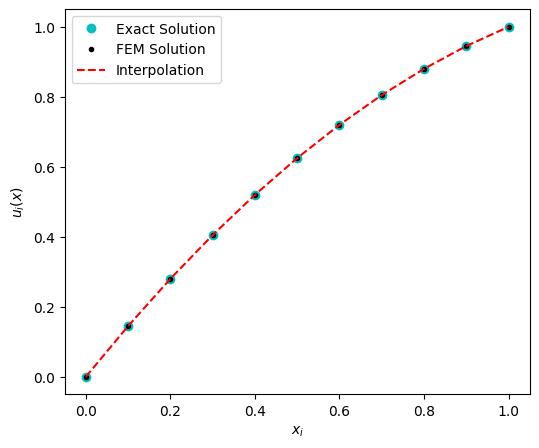

In [7]:
#Plot the solution with FEM and analytical sol
def exact( x ):
    u = - x*(x - 3)/2
    return u

plt.figure(figsize=(6, 5))
plt.plot(xi, exact(xi),'co', label='Exact Solution')
plt.plot(xi, sol,'k.', label='FEM Solution')
plt.plot(x_new, y_new,'r--', label='Interpolation')
plt.xlabel(r'$x_i$')
plt.ylabel(r'$u_i(x)$')
plt.legend(loc='best')
plt.show()

### Exercise: solve the EDO

Use FEM to solve the next EDO (use the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
\dfrac{d^2y}{dx^2}=-xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(2-x)-x
\end{equation}

### Example 2: Solve the EDO:  

see pag 36: https://cimec.org.ar/foswiki/pub/Main/Cimec/CursoFEM/cursofem_1.pdf

$-\dfrac{d^2U}{dx^2}(x)=\sin(\pi x)\,,$ 
in $0\le x\le 1$, with $U(0)=U(1)=0$. 

The exact solution is known $U(x)=\dfrac{1}{\pi^2}\sin(\pi x)$.

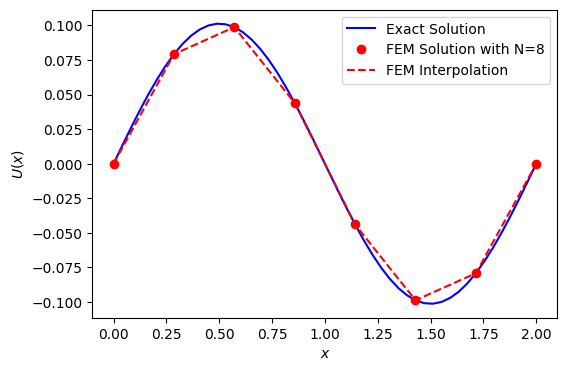

In [13]:
# In this case we know the solution
def exact(x):
    u = (1./np.pi**2)*np.sin(np.pi*x)
    return u

# F funtion
def f(x):
  return np.sin(np.pi*x)

#Import my own rutine (Exercise 1)
from FEM import *

#FEM Solution
xa, xb = 0, 2 #Initial conditions
x_new = np.linspace(xa,xb)
# Number of nodos
N = 8
x_int, y_int = FEM(N,f,xa,xb,0,0)[0], FEM(N,f,xa,xb,0,0)[1]
#Interpolation
y_new = np.interp(x_new, x_int, y_int)

#Plot the solution with FEM and analytical sol
plt.figure(figsize=(6, 4))
x = np.linspace(xa,xb)
plt.plot(x, exact(x),'b-', label='Exact Solution')
plt.plot(x_int, y_int,'ro', label='FEM Solution with N=%.1d'%N)
plt.plot(x_new, y_new,'r--', label='FEM Interpolation')
plt.xlabel(r'$x$')
plt.ylabel(r'$U(x)$')
plt.legend(loc='best')
#plt.grid()
plt.show()

### Referencias:
- Rubin H Landau, Manuel J. Páez, Cristian BOrdeianu, Computational Physics, 3rd Ed, (2015), Wiley VCH, Winheim, Germany.
- Hughes, T.J.R. "The Finite Element Method: Linear Static and Dynamic Finite Element Analysis"
- Zienkiewicz, O.C. "The Finite Element Method"

## FEM  2D in process...

Solve $-Δu(x,y) = f(x,y)$ in $[0,1]×[0,1]$ with Dirichlet boundary conditions $u=0$ in the border.
(Usaremos una malla rectangular con elementos cuadriláteros y aproximación bilineal).

... in process